### Scikit Neural Network

Mean absolute error=0.586


Text(0, 0.5, 'Distance (m)')

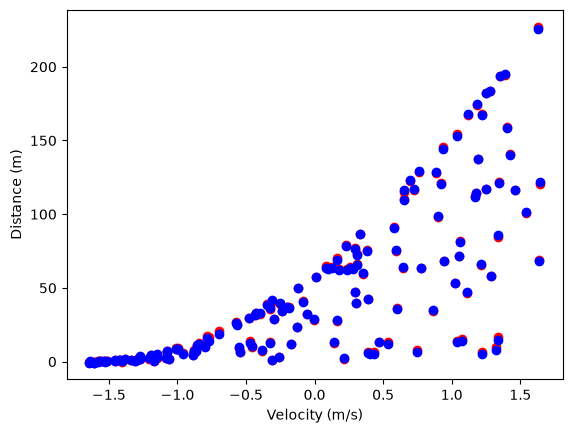

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

X = np.load('data_X.npy')
Y = np.load('data_Y.npy')
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MLP = multi layer perceptron
mlp = MLPRegressor(hidden_layer_sizes=(50, 25, 12, 6, 3), activation='relu', solver='adam', max_iter=10000, verbose=False)
mlp.fit(X_train, y_train)
predictions = mlp.predict(X_test)
print(f"Mean absolute error={mean_absolute_error(y_test, predictions):.3f}")

plt.scatter(X_test[:,1], y_test, c='r')
plt.scatter(X_test[:,1], predictions, c='b')
plt.xlabel('Velocity (m/s)')
plt.ylabel('Distance (m)')

### Redo with csv-files

Mean absolute error=46.411


/home/jorgen/Documents/MegaMachineLearn/Project_02_Hammer_Throw/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10000) reached and the optimization hasn't converged yet.
  warnings.warn(


Text(0, 0.5, 'Distance (m)')

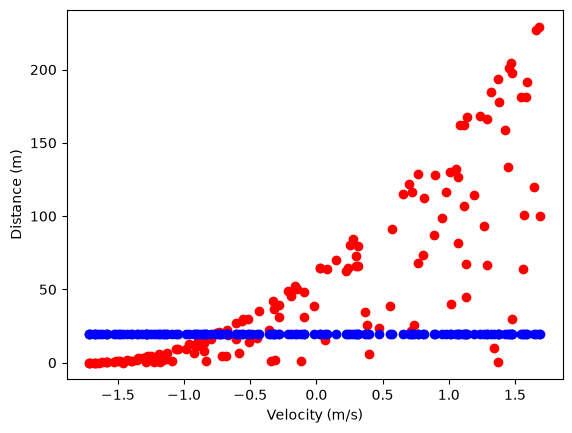

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

X = np.genfromtxt('data_X.csv', delimiter=',')
Y = np.genfromtxt('data_Y.csv', delimiter=',')
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MLP = multi layer perceptron
mlp = MLPRegressor(hidden_layer_sizes=(50, 25, 12, 6, 3), activation='relu', solver='adam', max_iter=10000, verbose=False)
mlp.fit(X_train, y_train)
predictions = mlp.predict(X_test)
print(f"Mean absolute error={mean_absolute_error(y_test, predictions):.3f}")

plt.scatter(X_test[:,1], y_test, c='r')
plt.scatter(X_test[:,1], predictions, c='b')
plt.xlabel('Velocity (m/s)')
plt.ylabel('Distance (m)')

### Try different network sizes

In [3]:
mlp = MLPRegressor(hidden_layer_sizes=(80, 80, 80, 80), activation='relu', solver='adam', max_iter=10000, verbose=False)
mlp.fit(X_train, y_train)
predictions = mlp.predict(X_test)
print(f"Mean absolute error={mean_absolute_error(y_test, predictions):.3f}")

Mean absolute error=0.328


In [4]:
mlp = MLPRegressor(hidden_layer_sizes=(500, 500, 500, 500, 500), activation='relu', solver='adam', max_iter=50000, verbose=False)
mlp.fit(X_train, y_train)
predictions = mlp.predict(X_test)
print(f"Mean absolute error={mean_absolute_error(y_test, predictions):.3f}")

Mean absolute error=0.253


In [5]:
mlp = MLPRegressor(hidden_layer_sizes=(50, 25, 12, 6, 3), activation='relu', solver='adam', max_iter=50000, verbose=False)
mlp.fit(X_train, y_train)
predictions = mlp.predict(X_test)
print(f"Mean absolute error={mean_absolute_error(y_test, predictions):.3f}")

Mean absolute error=0.518


#### Hyperparameter Optimization

In [6]:
from sklearn.model_selection import GridSearchCV

parameter_space = {
    'hidden_layer_sizes': [(50,50,50), (50,100,50), (100,100,100,100)],
    'activation': ['tanh', 'relu'],
    'alpha': [0.0001, 0.05],
}

#     'solver': ['sgd', 'adam'],
#    'learning_rate': ['constant','adaptive'],

print("Start grid search")
clf = GridSearchCV(mlp, parameter_space, n_jobs=-1, return_train_score=True, verbose=3)
clf.fit(X_train, y_train)

print(f"Best parameters: {clf.best_params_}")

predictions = clf.predict(X_test)
print(f"Mean absolute error={mean_absolute_error(y_test, predictions):.3f}")

Start grid search
Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50, 50, 50);, score=(train=1.000, test=1.000) total time=   1.0s
[CV 2/5] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50, 50, 50);, score=(train=1.000, test=1.000) total time=   1.1s
[CV 3/5] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50, 50, 50);, score=(train=1.000, test=1.000) total time=   1.4s
[CV 4/5] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50, 50, 50);, score=(train=1.000, test=1.000) total time=   1.3s
[CV 3/5] END activation=tanh, alpha=0.05, hidden_layer_sizes=(50, 50, 50);, score=(train=0.998, test=0.988) total time=   2.9s
[CV 1/5] END activation=tanh, alpha=0.05, hidden_layer_sizes=(50, 50, 50);, score=(train=0.996, test=0.994) total time=   2.9s
[CV 4/5] END activation=tanh, alpha=0.05, hidden_layer_sizes=(50, 50, 50);, score=(train=0.997, test=1.000) total time=   2.9s
[CV 4/5] END activation=